# 03 — Stationarity and Variable Transformation

This notebook checks the stationarity of the variables used in the SARIMA and VAR analyses. The Augmented Dickey–Fuller test is first applied to each variable in levels. Variables found to be non-stationary are transformed into monthly log changes and tested again.

The notebook then prepares and exports the stationary dataset used for the VAR model. No forecasting models are estimated here.

In [69]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.tseries.offsets import MonthEnd
from statsmodels.tsa.stattools import adfuller

In [6]:
# Titles and axis labels used in the plots

plot_info = {
    "Inflation": {
        "title": "Monthly Inflation in Peru (1995–2025)",
        "ylabel": "Monthly Inflation (%)"
    },
    "GDP": {
        "title": "Gross Domestic Product Index",
        "ylabel": "GDP Index (2007 = 100)"
    },
    "Exchange Rate": {
        "title": "Multilateral Real Effective Exchange Rate",
        "ylabel": "REER Index (2009 = 100)"
    },
    "Interest": {
        "title": "Monetary Policy Reference Interest Rate",
        "ylabel": "Interest Rate (%)"
    },
    "Liquidity": {
        "title": "Banking System Liquidity",
        "ylabel": "Liquidity (Million S/)"
    }
}

**Load the prepared datasets**

The complete inflation dataset is loaded for the univariate analysis. The multivariate dataset contains inflation, GDP, the real effective exchange rate, the policy interest rate and liquidity over their common study period.

In [7]:
# Load datasets
sarima_inf = pd.read_csv("/content/drive/MyDrive/MSc_Dissertation/datasets/processed/df_inflation_sarima.csv")
multivar_inf = pd.read_csv("/content/drive/MyDrive/MSc_Dissertation/datasets/processed/merged.csv")

print("SARIMA dataset:")
display(sarima_inf.head())
print()

print("Multivariate dataset:")
display(multivar_inf.head())

SARIMA dataset:


,Date,Inflation
0,1995-01-31,0.372189
1,1995-02-28,1.136291
2,1995-03-31,1.372020
3,1995-04-30,0.984568
4,1995-05-31,0.834709



Multivariate dataset:


,Date,Inflation,GDP,Exchange Rate,Interest,Liquidity
0,2003-09-30,0.558598,73.867835,100.492827,2.75,18669.571905
1,2003-10-31,0.049032,77.598914,101.854399,2.75,18795.623996
2,2003-11-30,0.167685,75.572539,102.125159,2.50,19113.295522
3,2003-12-31,0.563951,78.009732,102.395661,2.50,19812.133396
4,2004-01-31,0.537447,75.913267,103.202148,2.50,20326.727396


**Prepare the time-series datasets**

Copies of the imported datasets are created to preserve the original dataframes. Their dates are converted to datetime values, sorted chronologically and set as the time-series index.

In [8]:
# Create copies to preserve the original datasets

sarima_stationarity = sarima_inf.copy()
multivar_stationarity = multivar_inf.copy()

In [9]:
# Ensure the Date column is datetime

sarima_stationarity["Date"] = pd.to_datetime(sarima_stationarity["Date"])
multivar_stationarity["Date"] = pd.to_datetime(multivar_stationarity["Date"])

# Sort observations chronologically

sarima_stationarity = sarima_stationarity.sort_values("Date")
multivar_stationarity = multivar_stationarity.sort_values("Date")

# Set Date as the index

sarima_stationarity = sarima_stationarity.set_index("Date")
multivar_stationarity = multivar_stationarity.set_index("Date")

In [10]:
# Verify datasets

print("SARIMA dataset")
print("Shape:", sarima_stationarity.shape)
print("Index type:", sarima_stationarity.index.dtype)
print(
    "Date range:",
    sarima_stationarity.index.min().date(),
    "to",
    sarima_stationarity.index.max().date()
)
print("Chronologically sorted:", sarima_stationarity.index.is_monotonic_increasing)

print()

print("Multivariate dataset")
print("Shape:", multivar_stationarity.shape)
print("Index type:", multivar_stationarity.index.dtype)
print(
    "Date range:",
    multivar_stationarity.index.min().date(),
    "to",
    multivar_stationarity.index.max().date()
)
print("Chronologically sorted:", multivar_stationarity.index.is_monotonic_increasing)

SARIMA dataset
Shape: (372, 1)
Index type: datetime64[ns]
Date range: 1995-01-31 to 2025-12-31
Chronologically sorted: True

Multivariate dataset
Shape: (268, 5)
Index type: datetime64[ns]
Date range: 2003-09-30 to 2025-12-31
Chronologically sorted: True


**Data-quality and continuity checks**

The datasets are checked for duplicated dates, missing values, numerical data types and missing monthly observations before stationarity testing begins.

In [11]:
print("SARIMA dataset")
print("Duplicate dates:", sarima_stationarity.index.duplicated().sum())

print("Missing values:")
display(sarima_stationarity.isna().sum())

print("Data types:")
display(sarima_stationarity.dtypes)

print()

print("Multivariate dataset")
print("Duplicate dates:", multivar_stationarity.index.duplicated().sum())

print("Missing values:")
display(multivar_stationarity.isna().sum())

print("Data types:")
display(multivar_stationarity.dtypes)

SARIMA dataset
Duplicate dates: 0
Missing values:


,0
Inflation,0


Data types:


,0
Inflation,float64



Multivariate dataset
Duplicate dates: 0
Missing values:


,0
Inflation,0
GDP,0
Exchange Rate,0
Interest,0
Liquidity,0


Data types:


,0
Inflation,float64
GDP,float64
Exchange Rate,float64
Interest,float64
Liquidity,float64


In [12]:
# Check for missing months

expected_sarima_dates = pd.date_range(
    sarima_stationarity.index.min(),
    sarima_stationarity.index.max(),
    freq="ME")

expected_multivar_dates = pd.date_range(
    multivar_stationarity.index.min(),
    multivar_stationarity.index.max(),
    freq="ME")

missing_sarima_dates = expected_sarima_dates.difference(sarima_stationarity.index)
missing_multivar_dates = expected_multivar_dates.difference(multivar_stationarity.index)

print("Missing months in SARIMA dataset:", len(missing_sarima_dates))
print("Missing months in multivariate dataset:", len(missing_multivar_dates))

if len(missing_sarima_dates) > 0:
    display(missing_sarima_dates)

if len(missing_multivar_dates) > 0:
    display(missing_multivar_dates)

Missing months in SARIMA dataset: 0
Missing months in multivariate dataset: 0


# Augmented Dickey–Fuller test

The Augmented Dickey–Fuller test checks whether a series contains a unit root.

Null hypothesis (H0): the series has a unit root and is non-stationary.
Alternative hypothesis (H1): the series is stationary.
Significance level: 5%.

The null hypothesis is rejected when the p-value is below 0.05. The lag length is selected automatically using the Akaike Information Criterion.

The c specification includes a constant. The ct specification includes a constant and a time trend, and is used for variables with a clear long-term trend.

In [13]:
# Function for the Augmented Dickey-Fuller test

def run_adf_test(series, variable_name, regression="c"):
    series = series.dropna()

    result = adfuller(
        series,
        regression=regression,
        autolag="AIC")

    print("ADF Test:", variable_name)
    print("Regression specification:", regression)
    print("ADF statistic: {:.4f}".format(result[0]))
    print("p-value: {:.4f}".format(result[1]))
    print("Lags used:", result[2])
    print("Observations:", result[3])

    print("Critical values:")
    for level, value in result[4].items():
        print(" ", level + ":", "{:.4f}".format(value))

    if result[1] < 0.05:
        print("Conclusion: Reject H₀. The series is stationary.")
    else:
        print("Conclusion: Do not reject H₀. The series may be non-stationary.")

**Inflation in the SARIMA sample**

The ADF test is applied to the complete monthly inflation series used for the univariate analysis.

In [14]:
# ADF test for Inflation in the SARIMA sample

run_adf_test(
    sarima_stationarity["Inflation"],
    "Inflation — SARIMA sample")

ADF Test: Inflation — SARIMA sample
Regression specification: c
ADF statistic: -3.8622
p-value: 0.0023
Lags used: 13
Observations: 358
Critical values:
  1%: -3.4487
  5%: -2.8696
  10%: -2.5711
Conclusion: Reject H₀. The series is stationary.


**Interpretation: Inflation in the SARIMA sample**

The ADF test produced a statistic of −3.8622 and a p-value of 0.0023. Since the p-value is below 0.05, the null hypothesis of a unit root is rejected. Monthly inflation is therefore stationary in levels, or I(0), over the SARIMA sample. No differencing is needed.

**Inflation in the multivariate sample**

Inflation is also tested over the shorter multivariate study period because its stationarity must be established for the sample used in the VAR model.

In [15]:
# ADF test for Inflation in the multivariate sample

run_adf_test(
    multivar_stationarity["Inflation"],
    "Inflation — multivariate sample")

ADF Test: Inflation — multivariate sample
Regression specification: c
ADF statistic: -3.4024
p-value: 0.0109
Lags used: 13
Observations: 254
Critical values:
  1%: -3.4564
  5%: -2.8730
  10%: -2.5729
Conclusion: Reject H₀. The series is stationary.


**Interpretation: Inflation — multivariate sample**

The ADF test produced a statistic of −3.4024 and a p-value of 0.0109. Since the p-value is below 0.05, the null hypothesis of a unit root is rejected. Monthly inflation is therefore stationary in levels, or I(0), over the multivariate sample. No differencing is needed before including Inflation in the VAR model.

**Multivariate variables in levels**

The remaining multivariate variables are visually inspected and tested in levels. The deterministic specification of each ADF test is based on whether the plotted series displays a clear long-term trend.

**GDP in levels**

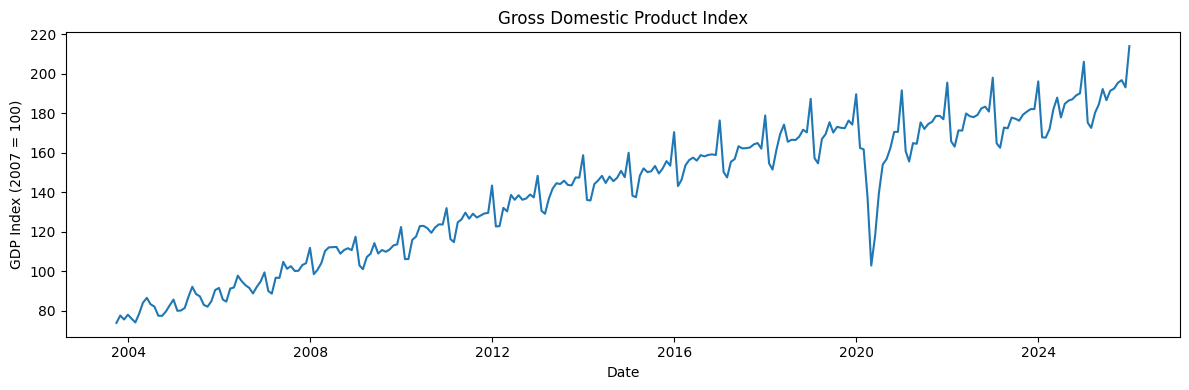

In [16]:
# Plot GDP in levels

plt.figure(figsize=(12, 4))
plt.plot(
    multivar_stationarity.index,
    multivar_stationarity["GDP"],
    linewidth=1.5)

plt.title(plot_info["GDP"]["title"])
plt.xlabel("Date")
plt.ylabel(plot_info["GDP"]["ylabel"])

plt.tight_layout()
plt.show()

The GDP series shows a sustained upward trend, interrupted by a sharp disruption around 2020–2021.

In [17]:
# ADF test for GDP in levels

run_adf_test(
    multivar_stationarity["GDP"],
    "GDP — level",
    regression="ct")

ADF Test: GDP — level
Regression specification: ct
ADF statistic: -2.5554
p-value: 0.3008
Lags used: 14
Observations: 253
Critical values:
  1%: -3.9950
  5%: -3.4280
  10%: -3.1373
Conclusion: Do not reject H₀. The series may be non-stationary.


**Interpretation: GDP in levels**

The GDP index shows a general upward trend over the sample period, with a sharp disruption around 2020–2021. For this reason, the ADF test included a constant and a time trend.

The test produced an ADF statistic of −2.5554 and a p-value of 0.3008. Since the p-value is above 0.05, the null hypothesis of a unit root cannot be rejected. The GDP index may therefore be non-stationary in levels and must be tested again after transformation.

This is a preliminary assessment of the original GDP series. The final VAR dataset uses the seasonally adjusted GDP series tested later in this notebook.

**Exchange Rate in levels**

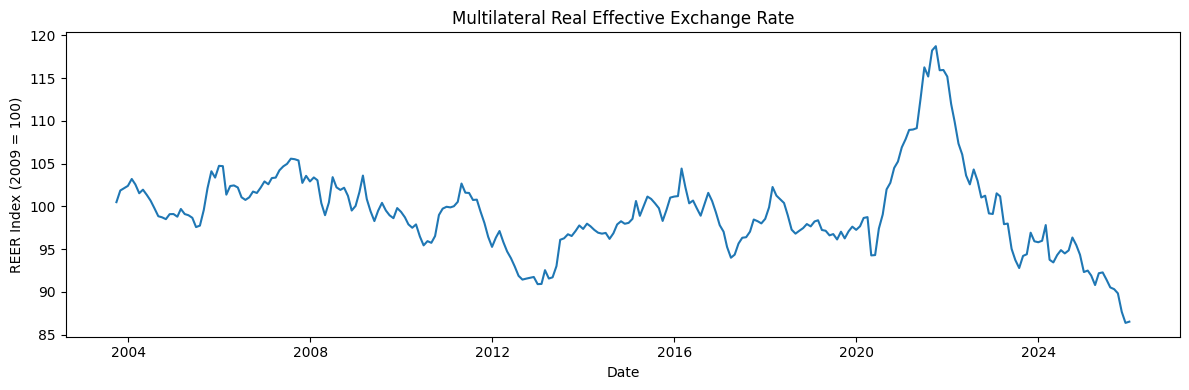

In [18]:
# Plot Exchange Rate in levels

plt.figure(figsize=(12, 4))
plt.plot(
    multivar_stationarity.index,
    multivar_stationarity["Exchange Rate"],
    linewidth=1.5)

plt.title(plot_info["Exchange Rate"]["title"])
plt.xlabel("Date")
plt.ylabel(plot_info["Exchange Rate"]["ylabel"])

plt.tight_layout()
plt.show()

The real effective exchange-rate index fluctuates at different levels throughout the sample, without a consistent linear trend. Its largest movement occurs around 2021, when it rises sharply before declining.

In [19]:
# ADF test for Exchange Rate in levels

run_adf_test(
    multivar_stationarity["Exchange Rate"],
    "Exchange Rate — level",
    regression="c")

ADF Test: Exchange Rate — level
Regression specification: c
ADF statistic: -2.2341
p-value: 0.1941
Lags used: 3
Observations: 264
Critical values:
  1%: -3.4554
  5%: -2.8726
  10%: -2.5726
Conclusion: Do not reject H₀. The series may be non-stationary.


Interpretation: Exchange Rate in levels

The real effective exchange-rate index does not show a consistent linear trend across the full sample. Therefore, the ADF test includes a constant but no time trend.

The test produced an ADF statistic of −2.2341 and a p-value of 0.1941. Since the p-value is above 0.05, the null hypothesis of a unit root cannot be rejected. The exchange rate may therefore be non-stationary in levels and must be tested again after transformation.

**Interest Rate in levels**

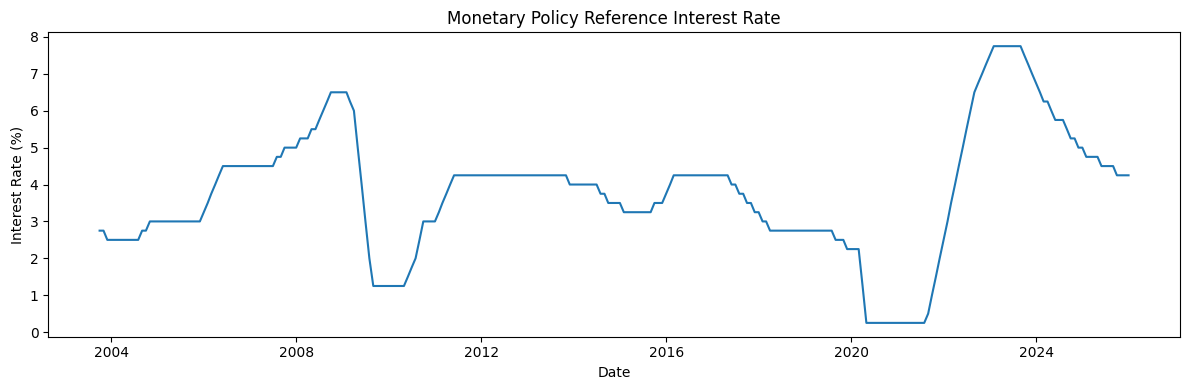

In [20]:
# Plot Interest Rate in levels

plt.figure(figsize=(12, 4))
plt.plot(
    multivar_stationarity.index,
    multivar_stationarity["Interest"],
    linewidth=1.5)

plt.title(plot_info["Interest"]["title"])
plt.xlabel("Date")
plt.ylabel(plot_info["Interest"]["ylabel"])

plt.tight_layout()
plt.show()

The monetary policy interest rate shows long periods of stability, interrupted by tightening and easing cycles. Major changes include the sharp reduction in 2009, the low interest rates around 2020–2021, and the rapid increases that began later in 2021. However, the series does not show a consistent linear trend across the full sample.

In [21]:
# ADF test for Interest Rate in levels

run_adf_test(
    multivar_stationarity["Interest"],
    "Interest Rate — level",
    regression="c")

ADF Test: Interest Rate — level
Regression specification: c
ADF statistic: -3.5512
p-value: 0.0068
Lags used: 6
Observations: 261
Critical values:
  1%: -3.4557
  5%: -2.8727
  10%: -2.5727
Conclusion: Reject H₀. The series is stationary.


Interpretation: Interest Rate in levels

The monetary policy interest rate shows long periods of stability, interrupted by periods of increases and reductions. However, it does not show a consistent linear trend across the full sample. Therefore, the ADF test includes a constant but no time trend.

The test produced an ADF statistic of −3.5512 and a p-value of 0.0068. Since the p-value is below 0.05, the null hypothesis of a unit root is rejected. The interest rate is therefore stationary in levels, or I(0), and no transformation is needed.

**Liquidity in levels**

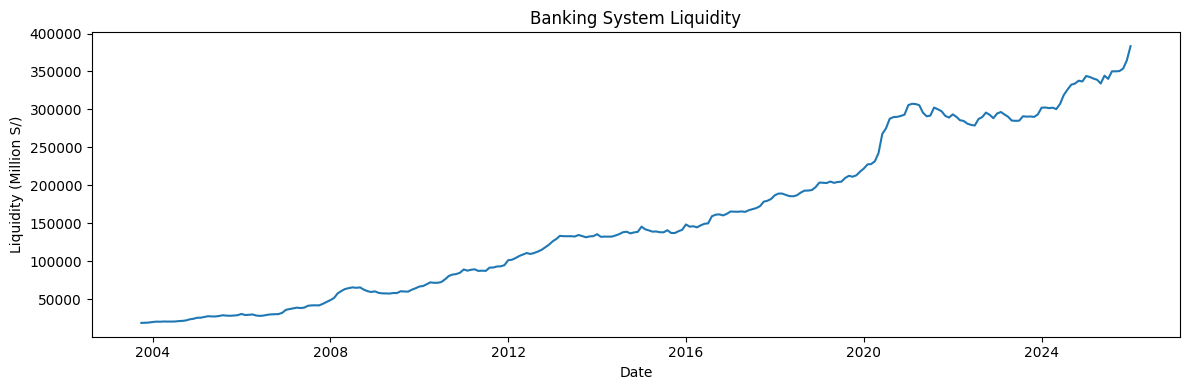

In [22]:
# Plot Liquidity in levels

plt.figure(figsize=(12, 4))
plt.plot(
    multivar_stationarity.index,
    multivar_stationarity["Liquidity"],
    linewidth=1.5)

plt.title(plot_info["Liquidity"]["title"])
plt.xlabel("Date")
plt.ylabel(plot_info["Liquidity"]["ylabel"])

plt.tight_layout()
plt.show()

The liquidity series shows a clear upward trend across the sample, despite temporary declines in some periods. A particularly large increase occurs around 2020–2021. Its fluctuations also appear larger when liquidity is at higher levels.

In [23]:
# ADF test for Liquidity in levels

run_adf_test(
    multivar_stationarity["Liquidity"],
    "Liquidity — level",
    regression="ct")

ADF Test: Liquidity — level
Regression specification: ct
ADF statistic: -1.6405
p-value: 0.7762
Lags used: 13
Observations: 254
Critical values:
  1%: -3.9949
  5%: -3.4279
  10%: -3.1373
Conclusion: Do not reject H₀. The series may be non-stationary.


Interpretation: Liquidity in levels

The liquidity series shows a clear upward trend across the sample. Therefore, the ADF test includes both a constant and a time trend.

The test produced an ADF statistic of −1.6405 and a p-value of 0.7762. Since the p-value is above 0.05, the null hypothesis of a unit root cannot be rejected. Liquidity may therefore be non-stationary in levels, even when a time trend is included. However, its order of integration cannot be determined from this result alone. Liquidity must be transformed and tested again before it can be classified as I(1).

# Replace GDP with the seasonally adjusted series

The original GDP index is replaced with the monthly seasonally adjusted GDP index. This series is prepared separately before being incorporated into the multivariate dataset.

**Load and prepare seasonally adjusted GDP**

The seasonally adjusted GDP series is loaded from its original BCRP file. Its column names and Spanish monthly dates are standardised before the prepared series is exported.

In [24]:
gdp_seas_adj = pd.read_csv("/content/drive/MyDrive/MSc_Dissertation/datasets/raw/gdp_seasonally_adjusted.csv", encoding='latin-1', skiprows=1)

In [25]:
gdp_seas_adj.head()

,Unnamed: 0,Producto bruto interno y demanda interna (índice 2007 = 100) - PBI Desestacionalizado - mensual
0,Ago03,78.129910
1,Sep03,78.347351
2,Oct03,78.908142
3,Nov03,75.209304
4,Dic03,75.752133


In [26]:
gdp_seas_adj.columns = ["Date", "GDP_Seasonally_Adjusted"]

In [27]:
month_map = {
    "Ene": "Jan",
    "Feb": "Feb",
    "Mar": "Mar",
    "Abr": "Apr",
    "May": "May",
    "Jun": "Jun",
    "Jul": "Jul",
    "Ago": "Aug",
    "Sep": "Sep",
    "Oct": "Oct",
    "Nov": "Nov",
    "Dic": "Dec"
}

In [28]:
gdp_seas_adj["Date"] = gdp_seas_adj["Date"].replace(month_map, regex=True)
gdp_seas_adj["Date"] = pd.to_datetime(gdp_seas_adj["Date"], format="%b%y")

In [29]:
gdp_seas_adj["Date"] = gdp_seas_adj["Date"] + MonthEnd(0)

In [30]:
gdp_seas_adj.info()
gdp_seas_adj.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269 entries, 0 to 268
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     269 non-null    datetime64[ns]
 1   GDP_Seasonally_Adjusted  269 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.3 KB


,Date,GDP_Seasonally_Adjusted
0,2003-08-31,78.129910
1,2003-09-30,78.347351
2,2003-10-31,78.908142
3,2003-11-30,75.209304
4,2003-12-31,75.752133


In [31]:
gdp_seas_adj.to_csv("/content/drive/MyDrive/MSc_Dissertation/datasets/processed/df_gdp_seas_adj.csv", index=False)

In [32]:
gdp_seas_adj.head()

,Date,GDP_Seasonally_Adjusted
0,2003-08-31,78.129910
1,2003-09-30,78.347351
2,2003-10-31,78.908142
3,2003-11-30,75.209304
4,2003-12-31,75.752133


**Calculate monthly GDP growth**

The natural logarithm of seasonally adjusted GDP is calculated. Its first difference is multiplied by 100 to obtain the approximate monthly percentage growth rate.

In [33]:
gdp_seas_adj = gdp_seas_adj.sort_values("Date").copy()

gdp_seas_adj["Log_GDP_SA"] = np.log(
    gdp_seas_adj["GDP_Seasonally_Adjusted"])

gdp_seas_adj["GDP_Growth"] = 100 * gdp_seas_adj["Log_GDP_SA"].diff()

gdp_seas_adj.head()

,Date,GDP_Seasonally_Adjusted,Log_GDP_SA,GDP_Growth
0,2003-08-31,78.129910,4.358373,NaN
1,2003-09-30,78.347351,4.361152,0.277920
2,2003-10-31,78.908142,4.368284,0.713227
3,2003-11-30,75.209304,4.320275,-4.800947
4,2003-12-31,75.752133,4.327467,0.719166


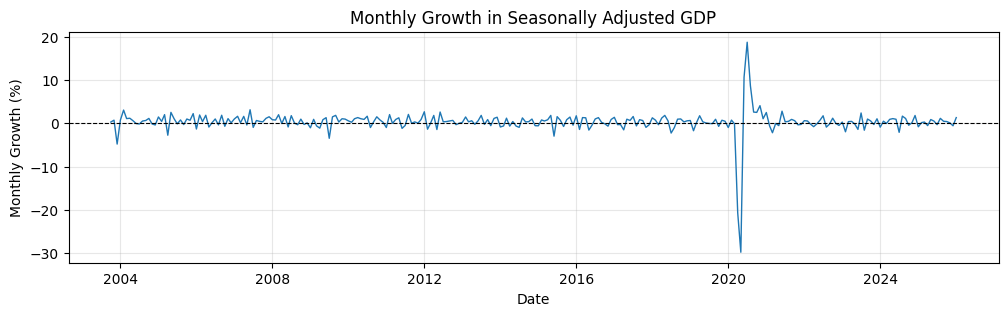

In [34]:
plt.figure(figsize=(12, 3))

plt.plot(
    gdp_seas_adj["Date"],
    gdp_seas_adj["GDP_Growth"],
    linewidth=1)

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.title("Monthly Growth in Seasonally Adjusted GDP")
plt.xlabel("Date")
plt.ylabel("Monthly Growth (%)")
plt.grid(alpha=0.3)

plt.show()

In [35]:
run_adf_test(
    gdp_seas_adj["Log_GDP_SA"],
    "Log seasonally adjusted GDP — level",
    regression="ct")

ADF Test: Log seasonally adjusted GDP — level
Regression specification: ct
ADF statistic: -2.7394
p-value: 0.2201
Lags used: 2
Observations: 266
Critical values:
  1%: -3.9932
  5%: -3.4271
  10%: -3.1368
Conclusion: Do not reject H₀. The series may be non-stationary.


In [36]:
run_adf_test(
    gdp_seas_adj["GDP_Growth"],
    "Seasonally adjusted GDP growth",
    regression="c")

ADF Test: Seasonally adjusted GDP growth
Regression specification: c
ADF statistic: -8.2721
p-value: 0.0000
Lags used: 7
Observations: 260
Critical values:
  1%: -3.4558
  5%: -2.8727
  10%: -2.5727
Conclusion: Reject H₀. The series is stationary.


**Stationarity of seasonally adjusted GDP**

The log level of seasonally adjusted GDP produced an ADF statistic of −2.7394 and a p-value of 0.2201. Since the p-value is above 0.05, the null hypothesis of a unit root cannot be rejected.

The monthly log difference produced an ADF statistic of −8.2721 and a p-value below 0.0001. The null hypothesis is rejected for GDP growth. The log GDP series is therefore treated as I(1), while its monthly growth rate is stationary and can be used in the VAR model.

# Incorporate seasonally adjusted GDP

The seasonally adjusted GDP variables are restricted to the common multivariate study period and merged into the working dataset using the monthly date. The original GDP column is removed before the replacement series is added.

In [37]:
gdp_seas_adj = (
    gdp_seas_adj[
        (gdp_seas_adj["Date"] >= "2003-09-30") &
        (gdp_seas_adj["Date"] <= "2025-12-31")].reset_index(drop=True))

In [38]:
gdp_seas_adj.head()

,Date,GDP_Seasonally_Adjusted,Log_GDP_SA,GDP_Growth
0,2003-09-30,78.347351,4.361152,0.277920
1,2003-10-31,78.908142,4.368284,0.713227
2,2003-11-30,75.209304,4.320275,-4.800947
3,2003-12-31,75.752133,4.327467,0.719166
4,2004-01-31,78.091980,4.357887,3.042076


In [39]:
gdp_seas_adj.describe()

,Date,GDP_Seasonally_Adjusted,Log_GDP_SA,GDP_Growth
count,268,268.000000,268.000000,268.000000
mean,2014-11-14 18:59:06.268656640,140.265081,4.910796,0.338260
min,2003-09-30 00:00:00,75.209304,4.320275,-29.740942
25%,2009-04-22 12:00:00,110.293069,4.703140,-0.310796
50%,2014-11-15 00:00:00,146.512960,4.987114,0.473802
75%,2020-06-07 12:00:00,171.127908,5.142411,1.070891
max,2025-12-31 00:00:00,193.429032,5.264911,18.689849
std,NaN,33.928311,0.264360,2.866038


In [40]:
multivar_inf.columns

Index(['Date', 'Inflation', 'GDP', 'Exchange Rate', 'Interest', 'Liquidity'], dtype='object')

In [41]:
multivar_inf = multivar_inf.drop(columns=["GDP"])

In [42]:
multivar_inf["Date"] = pd.to_datetime(multivar_inf["Date"])
gdp_seas_adj["Date"] = pd.to_datetime(gdp_seas_adj["Date"])

In [43]:
print("Duplicated GDP dates:", gdp_seas_adj["Date"].duplicated().sum())

Duplicated GDP dates: 0


In [44]:
multivar_inf = multivar_inf.merge(
    gdp_seas_adj[
        ["Date",
         "GDP_Seasonally_Adjusted",
         "Log_GDP_SA",
         "GDP_Growth"]],
    on="Date",
    how="left",
    validate="one_to_one")

multivar_inf = (multivar_inf.sort_values("Date").reset_index(drop=True))

In [45]:
print("Shape:", multivar_inf.shape)
print("Start date:", multivar_inf["Date"].min())
print("End date:", multivar_inf["Date"].max())

multivar_inf[
    ["Date",
     "GDP_Seasonally_Adjusted",
     "Log_GDP_SA",
     "GDP_Growth"
    ]].head()

Shape: (268, 8)
Start date: 2003-09-30 00:00:00
End date: 2025-12-31 00:00:00


,Date,GDP_Seasonally_Adjusted,Log_GDP_SA,GDP_Growth
0,2003-09-30,78.347351,4.361152,0.277920
1,2003-10-31,78.908142,4.368284,0.713227
2,2003-11-30,75.209304,4.320275,-4.800947
3,2003-12-31,75.752133,4.327467,0.719166
4,2004-01-31,78.091980,4.357887,3.042076


In [46]:
multivar_inf.head()

,Date,Inflation,Exchange Rate,Interest,Liquidity,GDP_Seasonally_Adjusted,Log_GDP_SA,GDP_Growth
0,2003-09-30,0.558598,100.492827,2.75,18669.571905,78.347351,4.361152,0.277920
1,2003-10-31,0.049032,101.854399,2.75,18795.623996,78.908142,4.368284,0.713227
2,2003-11-30,0.167685,102.125159,2.50,19113.295522,75.209304,4.320275,-4.800947
3,2003-12-31,0.563951,102.395661,2.50,19812.133396,75.752133,4.327467,0.719166
4,2004-01-31,0.537447,103.202148,2.50,20326.727396,78.091980,4.357887,3.042076


In [47]:
multivar_inf.describe()

,Date,Inflation,Exchange Rate,Interest,Liquidity,GDP_Seasonally_Adjusted,Log_GDP_SA,GDP_Growth
count,268,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000
mean,2014-11-14 18:59:06.268656640,0.258429,99.301809,3.787313,155823.109477,140.265081,4.910796,0.338260
min,2003-09-30 00:00:00,-0.527952,86.377724,0.250000,18669.571905,75.209304,4.320275,-29.740942
25%,2009-04-22 12:00:00,0.038021,96.592085,2.750000,62019.518403,110.293069,4.703140,-0.310796
50%,2014-11-15 00:00:00,0.225739,98.961832,4.000000,137980.040956,146.512960,4.987114,0.473802
75%,2020-06-07 12:00:00,0.436415,101.583934,4.500000,269412.362287,171.127908,5.142411,1.070891
max,2025-12-31 00:00:00,1.482660,118.729755,7.750000,383367.075281,193.429032,5.264911,18.689849
std,NaN,0.321947,4.993574,1.695585,103948.447514,33.928311,0.264360,2.866038


In [48]:
multivar_inf[
    ["GDP_Seasonally_Adjusted",
     "Log_GDP_SA",
     "GDP_Growth"
    ]].isna().sum()

,0
GDP_Seasonally_Adjusted,0
Log_GDP_SA,0
GDP_Growth,0


**Verify the updated multivariate dataset**

The updated dataset is checked for its dimensions, date range, duplicated dates, missing values and monthly continuity after seasonally adjusted GDP has been incorporated.

New dataset quality check

In [49]:
print("Shape:", multivar_inf.shape)
print("Start date:", multivar_inf["Date"].min())
print("End date:", multivar_inf["Date"].max())
print("Duplicated dates:", multivar_inf["Date"].duplicated().sum())

multivar_inf.isna().sum()

Shape: (268, 8)
Start date: 2003-09-30 00:00:00
End date: 2025-12-31 00:00:00
Duplicated dates: 0


,0
Date,0
Inflation,0
Exchange Rate,0
Interest,0
Liquidity,0
GDP_Seasonally_Adjusted,0
Log_GDP_SA,0
GDP_Growth,0


In [50]:
expected_dates = pd.date_range(
    start=multivar_inf["Date"].min(),
    end=multivar_inf["Date"].max(),
    freq="ME")

missing_dates = expected_dates.difference(multivar_inf["Date"])

print("Missing monthly dates:", len(missing_dates))
print(missing_dates)

Missing monthly dates: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='ME')


# Transform Exchange Rate and Liquidity

The natural logarithms of the real effective exchange rate and liquidity are calculated. Their first log differences are multiplied by 100 to produce approximate monthly percentage changes.

The first observation of each transformed series is missing by construction because calculating a first difference requires an observation from the preceding month.

In [51]:
multivar_inf["Log_Exchange_Rate"] = np.log(multivar_inf["Exchange Rate"])

multivar_inf["Exchange_Rate_Change"] = (100 * multivar_inf["Log_Exchange_Rate"].diff())

In [52]:
multivar_inf["Log_Liquidity"] = np.log(multivar_inf["Liquidity"])

multivar_inf["Liquidity_Growth"] = (100 * multivar_inf["Log_Liquidity"].diff())

In [53]:
multivar_inf[
    ["Date",
     "Exchange Rate",
     "Log_Exchange_Rate",
     "Exchange_Rate_Change",
     "Liquidity",
     "Log_Liquidity",
     "Liquidity_Growth"
    ]].head()

,Date,Exchange Rate,Log_Exchange_Rate,Exchange_Rate_Change,Liquidity,Log_Liquidity,Liquidity_Growth
0,2003-09-30,100.492827,4.610086,NaN,18669.571905,9.834650,NaN
1,2003-10-31,101.854399,4.623544,1.345797,18795.623996,9.841379,0.672905
2,2003-11-30,102.125159,4.626199,0.265478,19113.295522,9.858139,1.676012
3,2003-12-31,102.395661,4.628844,0.264523,19812.133396,9.894050,3.591035
4,2004-01-31,103.202148,4.636690,0.784533,20326.727396,9.919692,2.564209


**Inspect the transformed series**

The transformed Exchange Rate and Liquidity variables are plotted around zero to examine their monthly positive and negative movements.

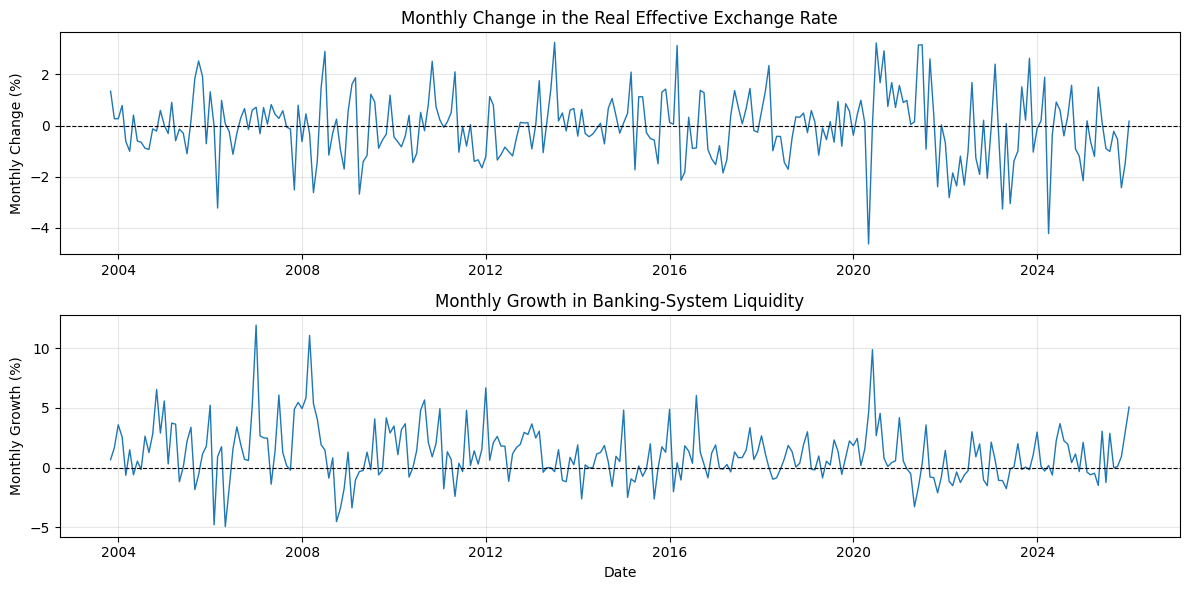

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(
    multivar_inf["Date"],
    multivar_inf["Exchange_Rate_Change"],
    linewidth=1)
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Monthly Change in the Real Effective Exchange Rate")
axes[0].set_ylabel("Monthly Change (%)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    multivar_inf["Date"],
    multivar_inf["Liquidity_Growth"],
    linewidth=1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Monthly Growth in Banking-System Liquidity")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Monthly Growth (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
run_adf_test(
    multivar_inf["Exchange_Rate_Change"],
    "Monthly change in the real effective exchange rate",
    regression="c")

ADF Test: Monthly change in the real effective exchange rate
Regression specification: c
ADF statistic: -13.5408
p-value: 0.0000
Lags used: 0
Observations: 266
Critical values:
  1%: -3.4552
  5%: -2.8725
  10%: -2.5726
Conclusion: Reject H₀. The series is stationary.


In [56]:
run_adf_test(
    multivar_inf["Liquidity_Growth"],
    "Monthly growth in banking-system liquidity",
    regression="c")

ADF Test: Monthly growth in banking-system liquidity
Regression specification: c
ADF statistic: -4.1532
p-value: 0.0008
Lags used: 14
Observations: 252
Critical values:
  1%: -3.4566
  5%: -2.8731
  10%: -2.5729
Conclusion: Reject H₀. The series is stationary.


In [57]:
run_adf_test(
    multivar_inf["Log_Exchange_Rate"],
    "Log real effective exchange rate — level",
    regression="c")

ADF Test: Log real effective exchange rate — level
Regression specification: c
ADF statistic: -2.0528
p-value: 0.2639
Lags used: 3
Observations: 264
Critical values:
  1%: -3.4554
  5%: -2.8726
  10%: -2.5726
Conclusion: Do not reject H₀. The series may be non-stationary.


In [58]:
run_adf_test(
    multivar_inf["Log_Liquidity"],
    "Log banking-system liquidity — level",
    regression="ct")

ADF Test: Log banking-system liquidity — level
Regression specification: ct
ADF statistic: -1.5807
p-value: 0.7999
Lags used: 15
Observations: 252
Critical values:
  1%: -3.9952
  5%: -3.4281
  10%: -3.1374
Conclusion: Do not reject H₀. The series may be non-stationary.


**Stationarity after transformation**

The log level of the real effective exchange rate remains non-stationary, with a p-value of 0.2639. Its monthly log change is stationary, with a p-value below 0.0001.

The log level of liquidity also remains non-stationary, with a p-value of 0.7999. Its monthly log growth rate is stationary, with a p-value of 0.0008.

The exchange rate and liquidity series are therefore treated as I(1). Their first log differences are stationary and can be included in the VAR model.

# Prepare the stationary VAR dataset

The VAR dataset contains Inflation and Interest in levels, together with GDP Growth, Exchange Rate Change and Liquidity Growth.

The missing values created by first differencing are removed. Consequently, the model-ready dataset begins in October 2003 rather than September 2003.

In [59]:
var_data = (
    multivar_inf[
        ["Date",
         "Inflation",
         "Interest",
         "GDP_Growth",
         "Exchange_Rate_Change",
         "Liquidity_Growth"
        ]].dropna().set_index("Date"))

var_data.head()

,Inflation,Interest,GDP_Growth,Exchange_Rate_Change,Liquidity_Growth
Date,,,,,
2003-10-31,0.049032,2.75,0.713227,1.345797,0.672905
2003-11-30,0.167685,2.50,-4.800947,0.265478,1.676012
2003-12-31,0.563951,2.50,0.719166,0.264523,3.591035
2004-01-31,0.537447,2.50,3.042076,0.784533,2.564209
2004-02-29,1.086085,2.50,1.079214,-0.619494,-0.634991


In [60]:
var_data.describe()

,Inflation,Interest,GDP_Growth,Exchange_Rate_Change,Liquidity_Growth
count,267.000000,267.000000,267.000000,267.000000,267.000000
mean,0.257304,3.791199,0.338486,-0.056062,1.131872
std,0.322024,1.697573,2.871418,1.285264,2.295184
min,-0.527952,0.250000,-29.740942,-4.637810,-4.931989
25%,0.037770,2.750000,-0.312438,-0.894057,-0.243884
50%,0.225030,4.000000,0.476332,-0.034073,0.850353
75%,0.432368,4.500000,1.070952,0.670582,2.181785
max,1.482660,7.750000,18.689849,3.255144,11.930470


**Correlation analysis of the VAR dataset after transformations**

In [67]:
correlation_matrix = var_data.corr()

correlation_matrix

,Inflation,Interest,GDP_Growth,Exchange_Rate_Change,Liquidity_Growth
Inflation,1.000000,0.100249,-0.056894,-0.246900,-0.043901
Interest,0.100249,1.000000,-0.026234,-0.183909,-0.104457
GDP_Growth,-0.056894,-0.026234,1.000000,0.244085,0.060124
Exchange_Rate_Change,-0.246900,-0.183909,0.244085,1.000000,-0.012131
Liquidity_Growth,-0.043901,-0.104457,0.060124,-0.012131,1.000000


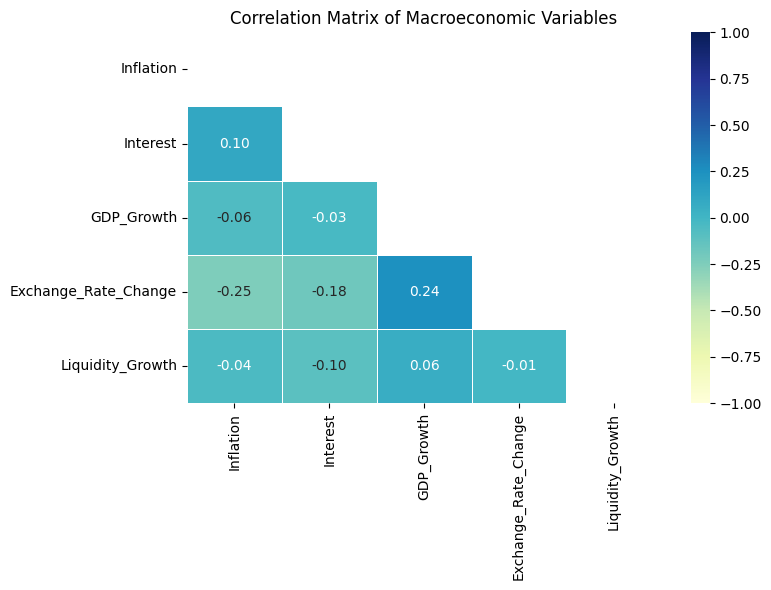

In [70]:
plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Macroeconomic Variables")
plt.tight_layout()
plt.show()

In [61]:
print("Shape:", var_data.shape)
print("Start date:", var_data.index.min())
print("End date:", var_data.index.max())
print("Duplicated dates:", var_data.index.duplicated().sum())

print()
print("Missing values:")
print(var_data.isna().sum())

Shape: (267, 5)
Start date: 2003-10-31 00:00:00
End date: 2025-12-31 00:00:00
Duplicated dates: 0

Missing values:
Inflation               0
Interest                0
GDP_Growth              0
Exchange_Rate_Change    0
Liquidity_Growth        0
dtype: int64


In [62]:
expected_dates = pd.date_range(
    start=var_data.index.min(),
    end=var_data.index.max(),
    freq="ME")

missing_dates = expected_dates.difference(var_data.index)

print("Expected observations:", len(expected_dates))
print("Actual observations:", len(var_data))
print("Missing monthly dates:", len(missing_dates))
print("Missing dates:", missing_dates.tolist())

Expected observations: 267
Actual observations: 267
Missing monthly dates: 0
Missing dates: []


**Prepare the additional log-level dataset**

A separate dataset containing the log levels of GDP, the Exchange Rate and Liquidity is retained from the preliminary methodological assessment. It is exported for completeness, but no Johansen test or VECM is estimated in the final empirical analysis.

In [63]:
coint_data = (
    multivar_inf[
        ["Date",
         "Log_GDP_SA",
         "Log_Exchange_Rate",
         "Log_Liquidity"]].dropna().set_index("Date"))

coint_data.head()

,Log_GDP_SA,Log_Exchange_Rate,Log_Liquidity
Date,,,
2003-09-30,4.361152,4.610086,9.834650
2003-10-31,4.368284,4.623544,9.841379
2003-11-30,4.320275,4.626199,9.858139
2003-12-31,4.327467,4.628844,9.894050
2004-01-31,4.357887,4.636690,9.919692


In [64]:
print("Shape:", coint_data.shape)
print("Start date:", coint_data.index.min())
print("End date:", coint_data.index.max())
print("Duplicated dates:", coint_data.index.duplicated().sum())

print()
print("Missing values:")
print(coint_data.isna().sum())

Shape: (268, 3)
Start date: 2003-09-30 00:00:00
End date: 2025-12-31 00:00:00
Duplicated dates: 0

Missing values:
Log_GDP_SA           0
Log_Exchange_Rate    0
Log_Liquidity        0
dtype: int64


# Export the final datasets

Three datasets are exported:

1. The complete transformed multivariate dataset, containing the original levels, log levels and stationary transformations.
2. The model-ready stationary dataset used for VAR estimation.
3. The additional log-level dataset retained from the preliminary cointegration assessment.

In [65]:
# Complete master dataset.
# Contains original levels, log levels, and transformed variables.
multivar_inf.to_csv("/content/drive/MyDrive/MSc_Dissertation/datasets/final_datasets/multivar_transformed.csv", index=False)

# Model-ready subset containing only the five stationary variables used to estimate the VAR
var_data.to_csv("/content/drive/MyDrive/MSc_Dissertation/datasets/final_datasets/var_data.csv", index=True)

# Dataset to test Cointegration
# Log-level dataset retained from the preliminary cointegration assessment
coint_data.to_csv("/content/drive/MyDrive/MSc_Dissertation/datasets/final_datasets/coint_data.csv", index=True)

**Final stationarity decisions**

Inflation and Interest are classified as I(0) and retained in levels.

Seasonally adjusted GDP, the real effective exchange rate and liquidity are treated as I(1). Their stationary monthly log changes are used in the VAR dataset.

The final VAR therefore contains five stationary variables. A VECM is not included because a separate system containing only GDP, the Exchange Rate and Liquidity would not provide the inflation-centred forecasting model required by this dissertation.